# 2.4. Calculus
D2L의 Calculus 장을 PyTorch 기준으로 정리함.
핵심은 미분, 수치미분, 접선, autograd, gradient, 편미분, chain rule이다.

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [ ]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

%matplotlib inline

import torch
import matplotlib
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Matplotlib backend:", matplotlib.get_backend())

PyTorch version: 2.11.0+cu128
Matplotlib backend: inline


## 1. 미분이 왜 필요한가?

딥러닝에서 모델은 보통

>예측값 계산  
> -> 정답과 비교해서 loss 계산  
> -> loss를 줄이는 방향으로 weight 수정

weight를 조금 키우면 loss가 커지나 작아지나, 얼마나 빨리 변하나?

이걸 알려주는게 미분값, 딥러닝에서 보통 gradient이다.
D2L에서는 미분을 함수 입력을 아주 조금 바꿨을 때 출력이 얼마나 변하는지로 설명한다.

## 2. 함수 하나 정의하기

D2L 예제 함수를 그대로 사용한다.
수식으로 쓰면 다음과 같다
$$
f(x) = 3x^2 - 4x
$$

이 함수의 미분은 다음과 같다.

$$
f'(x) = 6x - 4
$$

따라서 \(x = 1\) 일 때의 기울기는 다음과 같다.

$$
f'(1) = 6 \times 1 - 4 = 2
$$

>\(x = 1\) 근처에서 이 함수의 순간 기울기는 2이다.

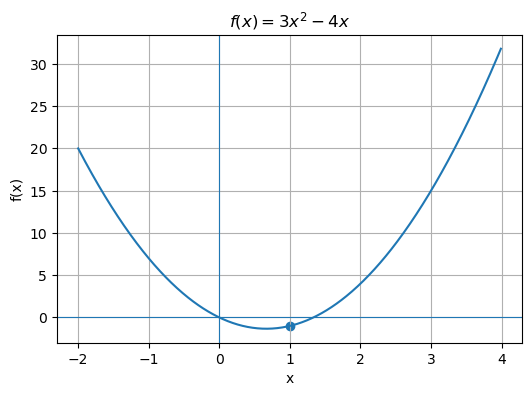

In [15]:
def f(x):
    return 3 * x ** 2 - 4 * x


x = torch.arange(-2.0, 4.0, 0.01)
y = f(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y)

plt.scatter([1], [f(torch.tensor(1.0))])

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x) = 3x^2 - 4x$")
plt.grid(True)

plt.show()

## 3. 수치적으로 미분값 확인하기

미분의 정의는 다음과 같다.
$$
f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

주의할 점은 컴퓨터는 부동소수점 오차가 있어 너무 작은 h에서 계산이 흔들릴 가능성이 있다.
그래서 수치미분은 개념확인용이고, 실제 딥러닝에서는 PyTorch autograd를 사용한다고 한다.

In [16]:
for h in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]: # h가 작아질수록 2에 가까워진다. 그래서 f'(1) = 2라고 볼 수 있다.
    numerical_limit = (f(1 + h) - f(1)) / h
    print(f"h={h:.5f}, numerical limit={numerical_limit:.5f}")

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


## 4. 접선 그려보기

앞에서 구한 함수
$$
f(x) = 3x^2 - 4x
$$
이 함수의 도함수
$$
f'(x) = 6x - 4
$$

\(x = 1\)에서의 기울기는 다음과 같다.

$$
f'(1) = 6 \times 1 - 4 = 2
$$

\(x = 1\)에서 접선의 기울기는 2이다.

---

접선은 원래 함수 위의 점을 지나야 한다.  
먼저 \(x = 1\)에서의 함수값을 계산하면 다음과 같다.

```python
f(torch.tensor(1.0))
```

출력 결과는 다음과 같다.

```text
tensor(-1.)
```

따라서 접선은 다음 점을 지나야 한다.

$$
(1, -1)
$$

접선의 기울기가 2이므로, 접선의 식을 다음과 같이 둘 수 있다.

$$
y = 2x + b
$$

이 직선이 \((1, -1)\)을 지나야 하므로,

$$
-1 = 2 \times 1 + b
$$

$$
b = -3
$$

따라서 \(x = 1\)에서의 접선은 다음과 같다.

$$
y = 2x - 3
$$

> 함수 \(f(x) = 3x^2 - 4x\)의 \(x = 1\)에서의 접선은 아래 수식이다. 
> $$
> y = 2x - 3
> $$
>  


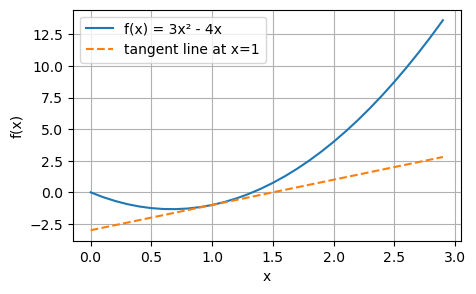

In [17]:
x = torch.arange(0, 3, 0.1)

y = f(x)
tangent = 2 * x - 3

plt.figure(figsize=(5, 3))
plt.plot(x, y, label="f(x) = 3x² - 4x")
plt.plot(x, tangent, "--", label="tangent line at x=1")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

## 5. PyTorch autograd로 미분하기

PyTorch에서 미분을 하려면 텐서에 requires_grad=True를 붙여야한다.
grad_fn이 있다는 건 PyTorch가 이 값이 어떤 연산을 통해 만들어졌는지 계산 그래프를 추적하고 있다는 뜻이다.

PyTorch 공식 문서에선 `.backward()`는 현재 텐서에 대해 그래프의 leaf tensor들의 gradient를 계산하며, chain rule을 사용한다.
그리고 계산된 gradient는 tensor의 `.grad` 속성에 저장된다.

[PyTorch `Tensor.backward` 문서](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.backward.html)

In [ ]:
x = torch.tensor(1.0, requires_grad=True)

y = f(x)
print(y)

y.backward() # 역전파
print(x.grad)

tensor(-1., grad_fn=<SubBackward0>)
tensor(2.)


## 6. grad가 누적되는 함정

PyTorch의 gradient는 기본적으로 누적된다.
그래서 다시 미분하기 전에 초기화가 필요하다.

In [19]:
x = torch.tensor(1.0, requires_grad=True)

y = f(x)
y.backward()
print(x.grad) # tensor(2.)

y = f(x)
y.backward()
print(x.grad) # tensor(4.)

x.grad = None # None으로 초기화

y = f(x)
y.backward()
print(x.grad) # tensor(2.)

# optimizer.zero_grad() # 실제 모델 학습에서는 보통 이렇게 한다고 한다.
# loss.backward()
# optimizer.step()

tensor(2.)
tensor(4.)
tensor(2.)


## 7. 여러 점에서 미분값 보기

앞에서 사용한 함수는 다음과 같다.

$$
f(x) = 3x^2 - 4x
$$

이 함수의 도함수는 다음과 같다.

$$
f'(x) = 6x - 4
$$

이번에는 하나의 점이 아니라 여러 점에서의 기울기를 PyTorch로 확인해본다.
`ys`가 스칼라 하나가 아니라 벡터이기 때문에 에러가 난다.

PyTorch의 `.backward()`는 기본적으로 스칼라 출력에 대해 가장 자연스럽게 동작한다.  
벡터 출력에 대해 미분하려면, 각 출력값을 어떤 방식으로 합쳐서 미분할지 알려줘야 한다.

가장 쉬운 건 출력값들을 합쳐서 하나의 스칼라로 만드는 것이다.
그러면 PyTorch는 다음 값을 미분한다.

$$
loss = f(0) + f(1) + f(2) + f(3)
$$

각 입력값에 대한 미분값은 다음과 같다.

$$
f'(x) = 6x - 4
$$

$$
f'(0) = -4
$$

$$
f'(1) = 2
$$

$$
f'(2) = 8
$$

$$
f'(3) = 14
$$

$$
[-4,\ 2,\ 8,\ 14]
$$

In [20]:
import torch

def f(x):
    return 3 * x ** 2 - 4 * x

xs = torch.tensor([0.0, 1.0, 2.0, 3.0], requires_grad=True)

ys = f(xs)
print("ys:", ys)

loss = ys.sum()
loss.backward()

print("xs.grad:", xs.grad)

ys: tensor([ 0., -1.,  4., 15.], grad_fn=<SubBackward0>)
xs.grad: tensor([-4.,  2.,  8., 14.])


## 8. 편미분과 Gradient

이제 입력 변수가 여러 개인 함수를 생각해보자.
예를 들어 다음 함수가 있다.

$$
g(x_1, x_2) = 3x_1^2 + 5e^{x_2}
$$

먼저 \(x_1\)에 대해 미분하면 다음과 같다.
$$
\frac{\partial g}{\partial x_1} = 6x_1
$$

이번에는 \(x_2\)에 대해 미분하면 다음과 같다.
$$
\frac{\partial g}{\partial x_2} = 5e^{x_2}
$$

D2L은 여러 변수 함수에서 각 변수에 대한 미분을 편미분이라고 한다. 모든 편미분을 모은 벡터를 gradient라고 설명한다.

$$
\nabla g =
\left[
\frac{\partial g}{\partial x_1},
\frac{\partial g}{\partial x_2}
\right]
$$

따라서 이 함수의 gradient는 다음과 같다.

$$
\nabla g =
[6x_1,\ 5e^{x_2}]
$$

\(x_1 = 1\), \(x_2 = 0\)에서 gradient를 계산해보자.

$$
\frac{\partial g}{\partial x_1} = 6 \times 1 = 6
$$

$$
\frac{\partial g}{\partial x_2} = 5e^0 = 5
$$

기대되는 gradient는 다음과 같다.
$$
[6,\ 5]
$$

In [21]:
import torch

x = torch.tensor([1.0, 0.0], requires_grad=True)

g = 3 * x[0] ** 2 + 5 * torch.exp(x[1])

g.backward()

print("g:", g)
print("x.grad:", x.grad)

g: tensor(8., grad_fn=<AddBackward0>)
x.grad: tensor([6., 5.])


## 9. Gradient의 의미

Gradient는 단순히 미분값을 모아놓은 것이 아니다.

`gradient`는 함수값을 가장 빠르게 증가시키는 방향을 나타낸다.  
반대로 `-gradient`는 함수값을 가장 빠르게 감소시키는 방향을 나타낸다.

딥러닝에서는 보통 loss를 최소화해야 한다. 그래서 파라미터를 gradient의 반대 방향으로 업데이트한다.

$$
w = w - learning\_rate * gradient
$$

### Gradient가 양수인 경우

$$
\frac{dL}{dw} > 0
$$

이 뜻은 \(w\)를 증가시키면 loss가 증가한다는 의미다.

따라서 loss를 줄이려면 \(w\)를 줄여야 한다.

$$
w = w - learning\_rate \cdot \text{positive gradient}
$$

### Gradient가 음수인 경우

$$
\frac{dL}{dw} < 0
$$

이 뜻은 \(w\)를 증가시키면 loss가 감소한다는 의미다.

따라서 loss를 줄이려면 \(w\)를 증가시켜야 한다.

$$
w = w - learning\_rate \cdot \text{negative gradient}
$$

> 정리하면, gradient는 loss가 증가하는 방향이고,  
> 딥러닝 학습에서는 그 반대 방향으로 움직여 loss를 줄인다.

In [22]:
w = torch.tensor(2.0, requires_grad=True)

loss = w ** 2

loss.backward()

print("w:", w.item())
print("loss:", loss.item())
print("gradient:", w.grad.item())

learning_rate = 0.1

with torch.no_grad():
    new_w = w - learning_rate * w.grad

print("new_w:", new_w.item())

w: 2.0
loss: 4.0
gradient: 4.0
new_w: 1.600000023841858


## 10. Chain Rule

Chain rule은 여러 함수가 합성되어 있을 때 미분을 연결해서 계산하는 규칙이다.

딥러닝에서는 여러 연산이 층층이 연결되어 있다.  
최종 loss를 각 파라미터에 대해 미분하려면 chain rule이 필요하다.

예를 들어서
$$
u = 2x
$$

$$
y = u^2
$$

이때 \(y\)는 \(u\)에 의해 결정되고, \(u\)는 다시 \(x\)에 의해 결정된다.

$$
x \rightarrow u \rightarrow y
$$

각각을 따로 미분하면 다음과 같다.

$$
\frac{dy}{du} = 2u
$$

$$
\frac{du}{dx} = 2
$$

chain rule에 따르면 \(y\)를 \(x\)에 대해 미분한 값은 다음과 같다.

$$
\frac{dy}{dx}
=
\frac{dy}{du}
\cdot
\frac{du}{dx}
$$

\(x = 3\)일 때

$$
u = 2x = 2 \times 3 = 6
$$

$$
\frac{dy}{du} = 2u = 2 \times 6 = 12
$$

$$
\frac{du}{dx} = 2
$$

$$
\frac{dy}{dx} = 12 \times 2 = 24
$$

\(x = 3\)에서의 미분값은 24이다.

PyTorch autograd는 이런 chain rule 계산을 자동으로 해준다. 공식 튜토리얼도 autograd를 신경망 학습을 지원하는 자동 미분 엔진으로 설명하고, 역전파에서 출력으로부터 거꾸로 이동하며 gradient를 수집한다고 설명한다.

[PyTorch autograd 튜토리얼](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html)

In [23]:
import torch

x = torch.tensor(3.0, requires_grad=True)

u = 2 * x
y = u ** 2

y.backward()

print("x:", x.item())
print("u:", u.item())
print("y:", y.item())
print("dy/dx:", x.grad.item())

x: 3.0
u: 6.0
y: 36.0
dy/dx: 24.0


## 11. 딥러닝식 예제로 연결하기

이제 미분을 딥러닝 학습 상황에 연결해보자.
단순한 선형 모델을 생각한다.

$$
\hat{y} = wx
$$

여기서 \(w\)는 모델이 학습해야 하는 파라미터이고, \(x\)는 입력값이다.
정답을 \(y\)라고 하면 loss는 다음처럼 둘 수 있다.

$$
L = (\hat{y} - y)^2
$$
$$
L = (wx - y)^2
$$

딥러닝 학습의 핵심은 이 loss를 줄이는 방향으로 \(w\)를 수정하는 것이다.
이를 위해서 \(w\)에 대한 loss의 미분값을 구한다.
$$
\frac{dL}{dw}
=
2(wx - y)x
$$

In [24]:
w = torch.tensor(2.0, requires_grad=True)

x = torch.tensor(3.0)
y_true = torch.tensor(10.0)

prediction = w * x
loss = (prediction - y_true) ** 2

print("prediction:", prediction.item())
print("loss:", loss.item())

loss.backward()

print("dL/dw:", w.grad.item())

prediction: 6.0
loss: 16.0
dL/dw: -24.0


직접 계산하면 다음과 같다.

$$
\hat{y} = wx = 2 \times 3 = 6
$$

$$
error = \hat{y} - y = 6 - 10 = -4
$$

$$
loss = (-4)^2 = 16
$$

gradient는 다음과 같다.
$$
\frac{dL}{dw}
=
2(wx - y)x
=
2(6 - 10)3
=
-24
$$

gradient가 음수라는 뜻은, \(w\)를 증가시키면 loss가 감소한다는 뜻이다.
경사하강법을 적용하면 \(w\)는 증가해야 한다.

## 12. gradient descent 업데이트 보기

앞 셀에서 구한 gradient를 이용해 \(w\)를 한 번 업데이트해본다.
실제 학습 루프의 `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()` 흐름을 손으로 축약한 예제다.

In [25]:
learning_rate = 0.01

with torch.no_grad():
    w -= learning_rate * w.grad

print("updated w:", w.item())

updated w: 2.240000009536743


업데이트 식은 다음과 같다.


$$
w = w - learning\_rate \times gradient
$$


현재 gradient는 (-24)이므로,


$$
w = 2 - 0.01 \times (-24)
$$


$$
w = 2.24
$$


즉, \(w\)가 커졌다.


이 상황에서는 예측값이 6이고 정답이 10이었으므로, 예측값을 키우기 위해 \(w\)가 커지는 것이 맞다.

## 13. 연습문제

아래 문제는 D2L 2.4 Exercises를 그대로 옮긴 것이 아니라,
해당 절의 핵심 개념을 PyTorch로 확인하기 위해 재구성한 문제이다.

D2L 원문 Exercises는 증명 중심 문제이므로, 더 보고 싶다면 아래 링크를 참고하면 된다.

[D2L 2.4.6 Exercises](https://d2l.ai/chapter_preliminaries/calculus.html#exercises)

### 문제 1. 수치미분과 autograd 비교하기

다음 함수를 정의하고, \(x=1\)에서의 기울기를 수치미분과 PyTorch autograd로 각각 확인해라.

$$
f(x) = x^3 - \frac{1}{x}
$$

직접 미분하면 다음과 같다.

$$
f'(x) = 3x^2 + \frac{1}{x^2}
$$

따라서 \(x=1\)에서의 정답은 다음과 같다.

$$
f'(1) = 4
$$

In [26]:
def f2(x):
    return x ** 3 - 1 / x

print("Numerical differentiation")

for h in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    numerical_limit = (f2(1 + h) - f2(1)) / h
    print(f"h={h:.5f}, numerical limit={numerical_limit:.5f}")

print("\nPyTorch autograd")

x = torch.tensor(1.0, requires_grad=True)
y = f2(x)
y.backward()

print("x.grad:", x.grad)

Numerical differentiation
h=0.10000, numerical limit=4.21909
h=0.01000, numerical limit=4.02020
h=0.00100, numerical limit=4.00200
h=0.00010, numerical limit=4.00020
h=0.00001, numerical limit=4.00002

PyTorch autograd
x.grad: tensor(4.)


### 문제 2. 여러 변수 함수의 gradient 구하기

다음 함수가 있다.

$$
g(x_1, x_2) = x_1^2 + x_1x_2 + x_2^2
$$

\(x_1=1\), \(x_2=2\)에서 gradient를 구해라.

직접 미분하면 다음과 같다.

$$
\frac{\partial g}{\partial x_1} = 2x_1 + x_2
$$

$$
\frac{\partial g}{\partial x_2} = x_1 + 2x_2
$$

따라서 기대값은 다음과 같다.

$$
[4,\ 5]
$$

In [27]:
x = torch.tensor([1.0, 2.0], requires_grad=True)

g = x[0] ** 2 + x[0] * x[1] + x[1] ** 2
g.backward()

print("g:", g.item())
print("x.grad:", x.grad)

g: 7.0
x.grad: tensor([4., 5.])


### 문제 3. D2L 공식 문제 일부: \(x^x\) 미분하기

D2L 공식 Exercises에는 다음 문제가 나온다.

$$
f(x) = x^x
$$

이 함수의 도함수를 구해라.

힌트는 양변에 로그를 취하는 것이다.

$$
y = x^x
$$

$$
\ln y = x \ln x
$$

양변을 \(x\)에 대해 미분하면,

$$
\frac{1}{y} \frac{dy}{dx} = \ln x + 1
$$
$$
\frac{dy}{dx} = y(\ln x + 1)
$$

원래 \(y = x^x\)이므로,

$$
\frac{d}{dx}x^x = x^x(\ln x + 1)
$$

이제 \(x=2\)에서 PyTorch autograd와 직접 계산 결과를 비교해보자.

In [28]:
x = torch.tensor(2.0, requires_grad=True)

y = x ** x
y.backward()

manual_grad = (x ** x) * (torch.log(x) + 1)

print("PyTorch grad:", x.grad.item())
print("Manual grad:", manual_grad.item())

PyTorch grad: 6.772588729858398
Manual grad: 6.772588729858398


## 14. 오늘의 정리

- 미분은 입력을 아주 조금 바꿨을 때 출력이 얼마나 변하는지를 나타내는 순간 변화율이다.
- 기울기가 양수이면 그 지점 근처에서 x를 조금 증가시킬 때 함수값이 증가하는 방향이라는 뜻이다.
- 기울기가 음수이면 그 지점 근처에서 x를 조금 증가시킬 때 함수값이 감소하는 방향이라는 뜻이다.
- 기울기가 0이면 그 지점에서 순간적으로 평평하다는 뜻이다. 단, 반드시 최솟값이나 최댓값이라는 뜻은 아니다.
- 수치미분은 미분의 정의를 직접 계산해서 기울기를 근사하는 방식이다.
- 수치미분은 개념 확인에는 좋지만, 실제 딥러닝 학습에서는 보통 PyTorch autograd를 사용한다.
- PyTorch에서 requires_grad=True를 설정하면 해당 텐서가 포함된 연산 그래프를 추적한다.
- .backward()를 호출하면 역전파를 통해 gradient를 계산한다.
- .backward()는 보통 스칼라 출력에 대해 사용하며, 벡터 출력은 합으로 줄이거나 gradient 인자를 지정해야 한다.
- 계산된 gradient는 보통 leaf tensor의 .grad에 저장된다.
- PyTorch의 gradient는 기본적으로 누적되므로 반복 학습 전에는 초기화해야 한다.
- 여러 변수에 대한 편미분값을 모은 벡터를 gradient라고 한다.
- gradient는 함수값이 가장 빠르게 증가하는 방향을 나타낸다.
- 딥러닝에서는 loss를 줄여야 하므로 보통 gradient의 반대 방향으로 파라미터를 업데이트한다.
- chain rule은 여러 연산이 연결된 함수의 미분을 계산하는 규칙이다.
- PyTorch autograd는 chain rule을 기반으로 gradient 계산을 자동으로 처리한다.